
# Taller: Deep Learning con MedMNIST, Perceptrón y CNN

## 1. Introducción

El Deep Learning (aprendizaje profundo) ha revolucionado el análisis de imágenes médicas, permitiendo automatizar tareas complejas como la detección de enfermedades, la segmentación de órganos y la predicción de resultados clínicos.
A diferencia del *Machine Learning clásico*, donde los modelos dependen de variables predefinidas o “features” diseñadas manualmente, el Deep Learning aprende representaciones jerárquicas directamente desde los datos, capturando patrones espaciales, texturales y morfológicos difíciles de expresar con reglas humanas.

En este taller, construiremos y entrenaremos dos redes neuronales fundamentales:

1. Perceptrón simple, el modelo más básico, que aplica una transformación lineal y una función de activación. Servirá como punto de partida para comprender los fundamentos del entrenamiento neuronal.
2. Red Convolucional (CNN), un modelo más avanzado que introduce capas convolucionales capaces de detectar bordes, formas y texturas, lo que la hace especialmente potente en imágenes biomédicas.

Usaremos la base de datos [MedMNIST](https://medmnist.com), un conjunto de datasets diseñados específicamente para docencia e investigación ligera en visión médica. Cada subdataset está preprocesado y balanceado, lo que permite centrarse en los conceptos del modelado y no en la recolección o limpieza de datos.

En particular, trabajaremos con:

* PneumoniaMNIST: imágenes de radiografía de tórax etiquetadas como *normal* o *neumonía*.
* OrganAMNIST: imágenes de tomografía computarizada (CT) abdominal con 11 clases correspondientes a distintos órganos.

Al finalizar, habrás recorrido todo el flujo de trabajo de un modelo de Deep Learning aplicado a salud, desde la carga de datos hasta la evaluación final, entendiendo cómo cada componente (datos, arquitectura, optimización y métricas) influye en el desempeño.



## 2. Objetivos


1. Cargar y explorar datasets biomédicos (PneumoniaMNIST y OrganAMNIST), entendiendo su estructura, formato y balance de clases.
2. Preparar el flujo de datos (`DataLoader` y `transforms`) para procesar imágenes en lotes (batches) y normalizarlas adecuadamente.
3. Implementar y entrenar un Perceptrón simple, observando sus limitaciones frente a datos visuales complejos.
4. Construir y entrenar una Red Convolucional (CNN) básica, interpretando su arquitectura y ventajas sobre el perceptrón.
5. Visualizar curvas de aprendizaje (*loss* y *accuracy*) para identificar comportamientos de sobreajuste y subajuste.
6. Evaluar el modelo mediante métricas relevantes en contexto médico: *accuracy*, *F1-score*, *sensibilidad* y *matriz de confusión*.
7. Extender el análisis a clasificación multiclase, entrenando modelos capaces de reconocer distintos órganos en OrganAMNIST.
8. (Opcional) Introducir conceptos de *data augmentation* y buenas prácticas para mejorar la generalización de modelos en salud.


## 3. Dataset

![](img/medmnist.png)



In [1]:
# Instalación de librerias
!pip install medmnist torch torchvision scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

from medmnist import PneumoniaMNIST, OrganAMNIST

from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 3.1. PneumoniaMNIST

PneumoniaMNIST es un conjunto de datos que contiene imágenes de rayos X de tórax etiquetadas para la detección de neumonía. Este dataset es una versión preprocesada y balanceada del conjunto original, lo que facilita su uso en tareas de clasificación binaria. Cuenta con 5,856 imágenes en total, divididas en conjuntos de entrenamiento, validación y prueba.


#### Ejercicio

Utilizando la documentación de MedMNIST, carga el dataset PneumoniaMNIST y explora su estructura:
1. Normaliza las imágenes segun su media y desviación estándar.  
2. Calcula la distribución percentual para cada uno de los sets (train, val, test)
3. Visualiza algunas imágenes con sus etiquetas correspondientes. Utiliza las imagenes de tamaño 64x64.


HINT: usa `transforms.ToTensor()` para convertir las imágenes a tensores.


Mean: 0.5716997385025024, Std: 0.1509079784154892
Número de imágenes en el set de entrenamiento: 4708, 80.40%
Número de imágenes en el set de validación: 524, 8.95%
Número de imágenes en el set de prueba: 624, 10.66%


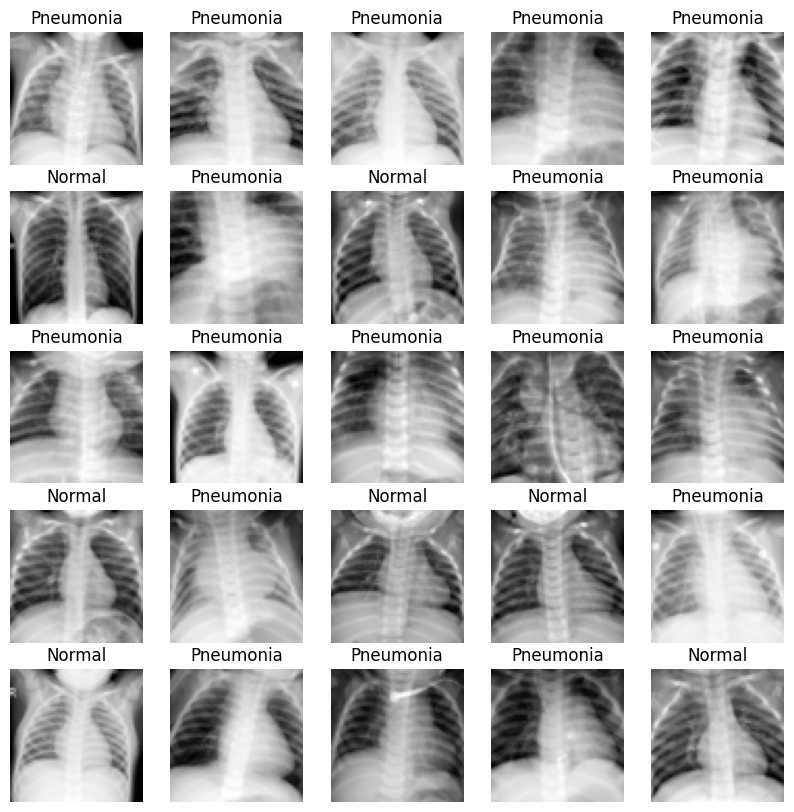

In [3]:
# <CODE>
transform = transforms.Compose([
    transforms.ToTensor(),
])
temp_dataset = PneumoniaMNIST(split="train", download=True, size=64, transform=transform)

# Calcular media y desviación estándar
mean = 0.0
std = 0.0
for x, _ in temp_dataset:
    mean += x.mean()
    std += x.std()
mean /= len(temp_dataset)
std /= len(temp_dataset)
print(f"Mean: {mean}, Std: {std}")



# Normalizar
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std]), #calcular a partir de los datos
])

train_dataset = PneumoniaMNIST(split="train", download=True, size=64, transform=data_transform)
val_dataset   = PneumoniaMNIST(split="val",   download=True, size=64, transform=data_transform)
test_dataset  = PneumoniaMNIST(split="test",  download=True, size=64, transform=data_transform)
idx2label = {0: "normal", 1: "pneumonia"}

N = len(train_dataset) + len(val_dataset) + len(test_dataset)

print(f"Número de imágenes en el set de entrenamiento: {len(train_dataset)}, {(len(train_dataset)/N)*100:.2f}%")
print(f"Número de imágenes en el set de validación: {len(val_dataset)}, {(len(val_dataset)/N)*100:.2f}%")
print(f"Número de imágenes en el set de prueba: {len(test_dataset)}, {(len(test_dataset)/N)*100:.2f}%")

# Visualización de algunas imágenes
plt.figure(figsize=(10, 10))

for i, (imagen, label) in enumerate(train_dataset):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(imagen[0], cmap='gray')
    plt.title(idx2label[label[0]].capitalize())
    plt.axis("off")
    if i == 24:
        break
plt.show()




## 4. Entrenamiento

A diferencia del *Machine Learning clásico*, donde era necesario definir manualmente las características (features) que describen los datos,como el tamaño, la textura o la intensidad promedio de una imagen, en Deep Learning las redes neuronales aprenden directamente esas representaciones de forma automática.
Esto significa que la imagen completa se entrega al modelo (como una matriz de pixeles), y las capas internas se encargan de extraer gradualmente los patrones relevantes para la tarea de clasificación. Las primeras capas suelen detectar bordes o texturas, mientras que las últimas capturan estructuras más complejas como formas anatómicas o lesiones.

El proceso de entrenamiento en Deep Learning sigue una receta bastante estandarizada que veremos en este taller:

1. Preparación del dataset: se cargan las imágenes y sus etiquetas, aplicando transformaciones como normalización o aumentos de datos (*data augmentation*).
   En PyTorch esto se realiza con las clases `Dataset` y `DataLoader`, que permiten entregar los datos en *batches* (grupos) durante el entrenamiento.

2. División de los datos: los datasets se separan en:

   * Entrenamiento (train) → usado para ajustar los parámetros de la red.
   * Validación (val) → usado durante el entrenamiento para verificar que el modelo no esté sobreajustando (*overfitting*).
   * Prueba (test) → usado solo al final, para medir el desempeño real del modelo en datos nunca vistos.

3. Entrenamiento por épocas: una *época* (epoch) corresponde a pasar todo el conjunto de entrenamiento una vez por la red.
   En cada iteración del *batch*, la red realiza:

   * una predicción (forward pass),
   * calcula una pérdida (loss) que mide el error,
   * y actualiza sus pesos mediante retropropagación (backpropagation) y optimización (por ejemplo, con Adam o SGD).

4. Validación periódica: al final de cada época, se evalúa el modelo en el conjunto de validación para observar si la pérdida disminuye y el *accuracy* mejora.
   Esto permite ajustar la cantidad de épocas, la tasa de aprendizaje o incluso detener el entrenamiento antes si ya no mejora (técnica conocida como *early stopping*).

En resumen, el entrenamiento de una red neuronal puede verse como una receta iterativa:

> preparar los datos → entrenar por épocas → validar → ajustar → evaluar en test.

Este flujo se implementará paso a paso en las siguientes secciones del taller, primero con un perceptrón simple y luego con una red convolucional (CNN) más potente.






#### **Ejercicio**

1. Define `BATCH_SIZE = 128`.
2. Crea tres `DataLoader`: `train_loader`, `val_loader`, `test_loader`.
   * `train_loader`: `shuffle=True`, `num_workers=2`, `pin_memory=True` (si hay GPU).
   * `val_loader` y `test_loader`: `shuffle=False`.
3. Extrae un batch de `train_loader` y muestra:

   * `x.shape` (imágenes) y `y.shape` (etiquetas).
   * Los valores únicos de `y` en el batch.
4. Responde:
   * ¿Existe un desbalance de clases en el batch? ¿Por qué podría ocurrir esto?
   * ¿Cómo afecta el `shuffle` a la distribución de clases en los batches?
   * ¿Cuál es el tamaño del batch y a que qué corresponde cada dimensión?



In [4]:
# <CODE>
BATCH_SIZE = 128
num_workers = 2

pin = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=pin, drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=pin, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=pin, drop_last=False)


# Verificar batch
x, y = next(iter(train_loader))  # y tiene forma (N,1)
y = y.float()          # -> (N,)

print("Shapes del batch:")
print("  x:", tuple(x.shape))    # (N, C=1, H=64, W=64)
print("  y:", tuple(y.shape))    # (N,)

vals, cnts = np.unique(y.numpy(), return_counts=True)
print("Etiquetas únicas en el batch:", dict(zip(vals.tolist(), cnts.tolist())))




Shapes del batch:
  x: (128, 1, 64, 64)
  y: (128, 1)
Etiquetas únicas en el batch: {0.0: 32, 1.0: 96}


## 5. Perceptrón simple (baseline)

El Perceptrón es la unidad básica de las redes neuronales y el punto de partida del Deep Learning.
Consiste en una capa lineal que multiplica las entradas (en este caso, los píxeles de la imagen) por un conjunto de pesos y aprende una frontera de decisión lineal entre las clases.

Aunque no captura patrones espaciales ni texturas, nos servirá como modelo de referencia para entender el proceso de entrenamiento y comparar luego con una red convolucional.
Cada imagen de 64×64 se “aplana” en un vector de 4096 valores, y el modelo aprende a separar normal de neumonía usando la función de pérdida.


#### **Ejercicio**
1.	Un modelo de Perceptron con tres capas nn.Linear. HINT: usa nn.Sequential
    * La primera capa debe tener como entrada 4096 (64*64) y como salida 512.
    * Capa de activación ReLU.
    * La segunda capa debe tener como entrada 512 y como salida 256.
    * Capa de activación ReLU.
    * La tercera capa debe tener como entrada 256 y como salida 1.
2. Utilizando un batch de `train_loader`, realiza un forward pass y muestra el tamaño de la salida.
3. Define la función de pérdida como `nn.BCEWithLogitsLoss()`.
4. Define el optimizador como `torch.optim.Adam` con tasa de aprendizaje `lr=0.001`.
 

In [5]:
# <CODE>
model = nn.Sequential(
    nn.Flatten(),  # Aplanar la imagen de entrada (1, 28, 28) -> (1*28*28)
    nn.Linear(1*64*64, 512),  # Capa oculta con 512 neuronas
    nn.ReLU(),                # Función de activación ReLU
    nn.Linear(512, 256),         # Capa oculta con 256 neuronas
    nn.ReLU(),                # Función de activación ReLU
    nn.Linear(256, 128),         # Capa oculta con 128 neuronas
    nn.ReLU(),                # Función de activación ReLU
    nn.Linear(128, 64),         # Capa oculta con 64 neuronas
    nn.ReLU(),                # Función de activación ReLU
    nn.Linear(64, 1),         # Capa de salida con 2 clases (normal/neumonía)
)


# Forward pass
model = model.to(device) # Mover el modelo a GPU si está disponible
x, y = next(iter(train_loader))
x, y = x.to(device), y.float().to(device)
logits = model(x)
print("Shape de los logits:", tuple(logits.shape))  # (N, 1)
print("Ejemplo de logits:", logits[:5].squeeze().detach().cpu().numpy())


loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


Shape de los logits: (128, 1)
Ejemplo de logits: [-0.13391879 -0.13058239 -0.13307199 -0.12741661 -0.12741993]


#### **Ejercicio**
1. Implementa el ciclo de entrenamiento para 20 épocas.
    * En cada época, itera sobre `train_loader` y realiza:
        * Forward pass.
        * Cálculo de la pérdida.
        * Backpropagation y optimización.
    * Al final de cada época, evalúa el modelo en `val_loader` y registra la pérdida y precisión.
2. Al finalizar el entrenamiento, evalúa el modelo en `test_loader` y calcula el loss y accuracy.
3. Grafica las curvas de pérdida y precisión para train y val a lo largo de las épocas.
4. Responde:
    * ¿Cómo se comporta la pérdida y precisión en train vs val? ¿Hay sobreajuste?
    * ¿Qué nos indica la matriz de confusión sobre los errores del modelo?  
    * ¿Comó se comporta las curvas de pérdida y accuracy al usar 100 épocas?

Epoch 1/20 | Train Loss: 0.2235, Train Acc: 0.8974 | Val Loss: 0.1295, Val Acc: 0.9504
Epoch 2/20 | Train Loss: 0.1214, Train Acc: 0.9522 | Val Loss: 0.1208, Val Acc: 0.9561
Epoch 3/20 | Train Loss: 0.1038, Train Acc: 0.9599 | Val Loss: 0.1034, Val Acc: 0.9542
Epoch 4/20 | Train Loss: 0.0921, Train Acc: 0.9684 | Val Loss: 0.1310, Val Acc: 0.9485
Epoch 5/20 | Train Loss: 0.0822, Train Acc: 0.9675 | Val Loss: 0.1482, Val Acc: 0.9447
Epoch 6/20 | Train Loss: 0.0637, Train Acc: 0.9754 | Val Loss: 0.1207, Val Acc: 0.9485
Epoch 7/20 | Train Loss: 0.0670, Train Acc: 0.9741 | Val Loss: 0.2060, Val Acc: 0.9389
Epoch 8/20 | Train Loss: 0.0761, Train Acc: 0.9701 | Val Loss: 0.1544, Val Acc: 0.9485
Epoch 9/20 | Train Loss: 0.0486, Train Acc: 0.9807 | Val Loss: 0.1349, Val Acc: 0.9523
Epoch 10/20 | Train Loss: 0.0394, Train Acc: 0.9841 | Val Loss: 0.1481, Val Acc: 0.9542
Epoch 11/20 | Train Loss: 0.0364, Train Acc: 0.9860 | Val Loss: 0.1167, Val Acc: 0.9542
Epoch 12/20 | Train Loss: 0.0335, Train A

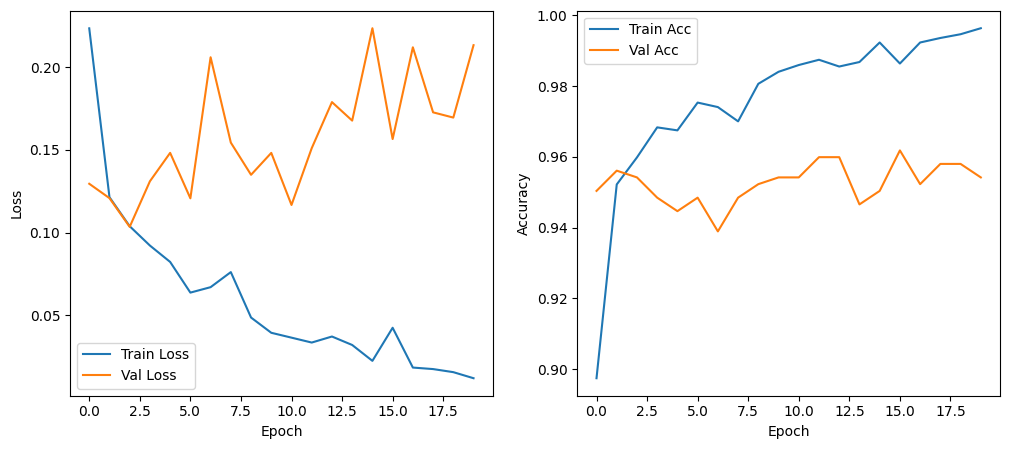

In [6]:
# <CODE>
# Definir función de entrenamiento por época
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        y = y.float()
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)    # Loss
        loss.backward()                # Backprop
        optimizer.step()               # Update
        # Métricas
        total_loss += loss.item() * x.size(0)
        p = torch.sigmoid(logits) >= 0.5 
        total_correct += (p == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

# Definir función de evaluación por época
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            y = y.float()
            x, y = x.to(device), y.to(device)
            logits = model(x)              # Forward
            loss = criterion(logits, y)    # Loss
            # Métricas
            total_loss += loss.item() * x.size(0)
            p = torch.sigmoid(logits) >= 0.5 

            total_correct += (p == y).sum().item()
            total += x.size(0)
    return total_loss/total, total_correct/total


epochs = 20
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, loss, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# eval test
test_loss, test_acc = eval_one_epoch(model, test_loader, loss, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

# plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



#### **Ejercicio**

En base al ejercicio anterior, manten la misma estructura pero crea multiples variaciones:
1. Learning rate a 0.1. ¿Cómo se comporta el entrenamiento? ¿Qué observas en las curvas de pérdida y accuracy?
2. Disminute el tamaño del modelo a 1 capas (4096→1) y 10 capas (4096→2048→1024→512→256→128→64→32→16→8→4→1). ¿Cómo afecta esto al desempeño?

Shape de los logits: (128, 1)
Ejemplo de logits: [-0.00757919 -0.03894183 -0.06472035  0.09598043  0.00547305]
Epoch 1/20 | Train Loss: 545.5565, Train Acc: 0.8154 | Val Loss: 8.0673, Val Acc: 0.8531
Epoch 2/20 | Train Loss: 5.1068, Train Acc: 0.9133 | Val Loss: 3.6368, Val Acc: 0.9084
Epoch 3/20 | Train Loss: 1.5715, Train Acc: 0.9184 | Val Loss: 0.8702, Val Acc: 0.9466
Epoch 4/20 | Train Loss: 0.4947, Train Acc: 0.9414 | Val Loss: 0.6034, Val Acc: 0.9427
Epoch 5/20 | Train Loss: 0.2328, Train Acc: 0.9475 | Val Loss: 0.2404, Val Acc: 0.9580
Epoch 6/20 | Train Loss: 0.1403, Train Acc: 0.9535 | Val Loss: 0.3532, Val Acc: 0.9523
Epoch 7/20 | Train Loss: 0.1527, Train Acc: 0.9535 | Val Loss: 0.6184, Val Acc: 0.9427
Epoch 8/20 | Train Loss: 0.3096, Train Acc: 0.9533 | Val Loss: 0.8640, Val Acc: 0.9389
Epoch 9/20 | Train Loss: 0.1815, Train Acc: 0.9554 | Val Loss: 0.6092, Val Acc: 0.9485
Epoch 10/20 | Train Loss: 0.2731, Train Acc: 0.9601 | Val Loss: 0.3087, Val Acc: 0.9542
Epoch 11/20 | Tr

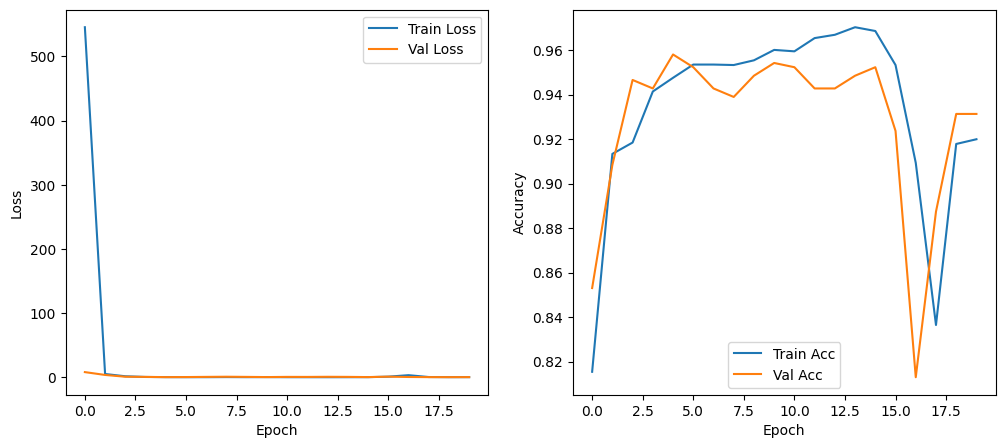

In [7]:
# <CODE>
model = nn.Sequential(
    nn.Flatten(),  # Aplanar la imagen de entrada (1, 28, 28) -> (1*28*28)
    nn.Linear(1*64*64, 512),  # Capa oculta con 512 neuronas
    nn.ReLU(),                # Función de activación ReLU
    nn.Linear(512, 256),         # Capa oculta con 256 neuronas
    nn.ReLU(),                # Función de activación ReLU
    nn.Linear(256, 1),         # Capa de salida con 2 clases (normal/neumonía)
)


# Forward pass
model = model.to(device)
x, y = next(iter(train_loader))
x, y = x.to(device), y.float().to(device)
logits = model(x)
print("Shape de los logits:", tuple(logits.shape))  # (N, 1)
print("Ejemplo de logits:", logits[:5].squeeze().detach().cpu().numpy())


loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)


# <CODE>
# Definir función de entrenamiento por época
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        y = y.float()
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)    # Loss
        loss.backward()                # Backprop
        optimizer.step()               # Update
        # Métricas
        total_loss += loss.item() * x.size(0)
        p = torch.sigmoid(logits) >= 0.5 
        total_correct += (p == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

# Definir función de evaluación por época
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            y = y.float()
            x, y = x.to(device), y.to(device)
            logits = model(x)              # Forward
            loss = criterion(logits, y)    # Loss
            # Métricas
            total_loss += loss.item() * x.size(0)
            p = torch.sigmoid(logits) >= 0.5 

            total_correct += (p == y).sum().item()
            total += x.size(0)
    return total_loss/total, total_correct/total


epochs = 20
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, loss, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# eval test
test_loss, test_acc = eval_one_epoch(model, test_loader, loss, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

# plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


